# 04 — Potential Outcomes y DAGs
**Autores clave:** Rubin (1974) · Holland (1986) · Pearl (2009) *Causality* · Imbens & Rubin (2015) *Causal Inference for Statistics* · Hernan & Robins (2020)

## Marco de Resultados Potenciales (Rubin, 1974)
Cada unidad $i$ tiene **dos resultados potenciales**:
- $Y_i(1)$: resultado bajo tratamiento
- $Y_i(0)$: resultado sin tratamiento

Solo uno es observable: $Y_i = D_i Y_i(1) + (1-D_i)Y_i(0)$

**Problema fundamental de la inferencia causal (Holland, 1986):** no podemos observar ambos resultados potenciales para la misma unidad al mismo tiempo.

## Efectos causales
$$\tau_i = Y_i(1) - Y_i(0) \quad \text{(efecto individual — no observable)}$$
$$ATE = E[Y(1) - Y(0)] = E[Y(1)] - E[Y(0)]$$
$$ATT = E[Y(1) - Y(0) | D=1]$$

## Ignorabilidad (CIA — Conditional Independence Assumption)
$$\{Y(0), Y(1)\} \perp\!\!\!\perp D \mid X$$
Si la asignación es ignorable dado $X$, entonces $E[Y(1)|X] = E[Y|D=1,X]$.

## DAGs (Pearl, 2009)
Grafos Acíclicos Dirigidos. Los nodos son variables; las aristas indican causalidad directa. Permiten leer independencias condicionales y criterios de identificación como el **backdoor criterion**.

In [1]:
import os
os.chdir('/Volumes/SSD_Gabo/proyectos/growth-analytics')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats
import statsmodels.api as sm

plt.rcParams.update({
    'figure.dpi': 130, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': '#e8e8e8', 'axes.axisbelow': True,
    'axes.titlesize': 11, 'axes.titleweight': 'bold', 'legend.frameon': False,
})
np.random.seed(42)

# Contexto: efecto de programa de capacitación laboral en salarios
# Confounder X = nivel educativo previo
n = 3000
TRUE_ATE = 2.0
TRUE_ATT = 2.5  # tratados tienen mayor beneficio

# X (confunder): educación previa
X_conf = np.random.normal(0, 1, n)  # estandarizada

# Propensity: probabilidad de tratarse (depende de X)
log_odds = -0.5 + 1.0 * X_conf
propensity = 1 / (1 + np.exp(-log_odds))
D = np.random.binomial(1, propensity, n).astype(float)

# Resultados potenciales (heterogéneos)
Y0 = 10 + 2.0*X_conf + np.random.normal(0, 1.5, n)
Y1 = Y0 + TRUE_ATE + 0.5*X_conf  # efecto mayor para más educados
Y  = np.where(D == 1, Y1, Y0)

df = pd.DataFrame({'Y': Y, 'D': D, 'X': X_conf,
                   'Y0': Y0, 'Y1': Y1, 'propensity': propensity})
df['tau_i'] = df['Y1'] - df['Y0']  # efecto individual (no observable en práctica)

print(f'ATE verdadero:   {df["tau_i"].mean():.4f}')
print(f'ATT verdadero:   {df[df["D"]==1]["tau_i"].mean():.4f}')
print(f'ATC verdadero:   {df[df["D"]==0]["tau_i"].mean():.4f}')
print(f'\nDiferencia bruta Y̅(D=1) - Y̅(D=0): {df[df["D"]==1]["Y"].mean() - df[df["D"]==0]["Y"].mean():.4f}')
print('← sobreestima el ATE porque tratados tienen mayor X (selección positiva)')

ATE verdadero:   2.0160
ATT verdadero:   2.2773
ATC verdadero:   1.8423

Diferencia bruta Y̅(D=1) - Y̅(D=0): 3.9240
← sobreestima el ATE porque tratados tienen mayor X (selección positiva)


## 1 — Visualizar el problema fundamental de la inferencia causal

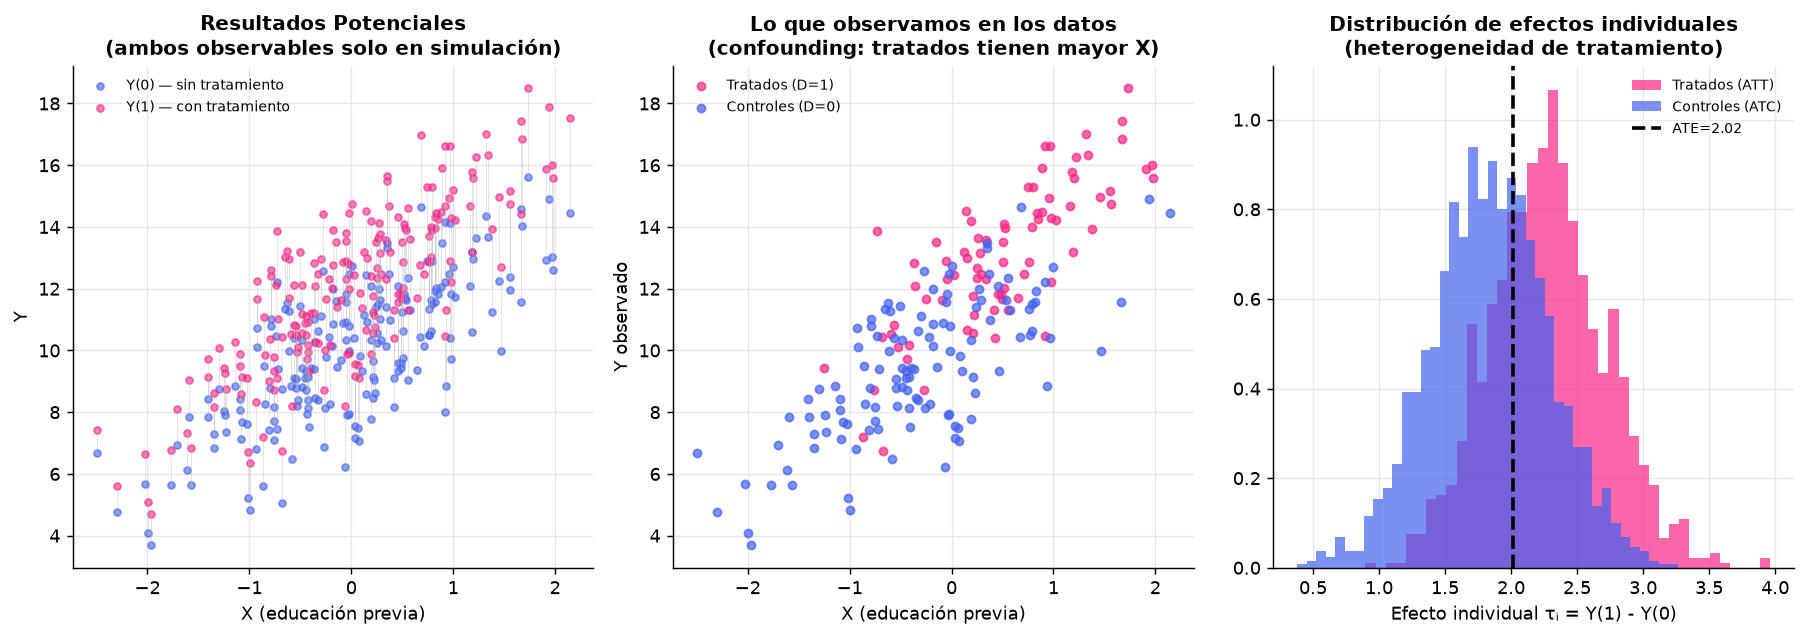

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# Panel A: resultados potenciales (mundos paralelos)
sample_idx = np.random.choice(n, 200, replace=False)
sample = df.iloc[sample_idx].sort_values('X')

axes[0].scatter(sample['X'], sample['Y0'], s=15, color='#4361ee', alpha=0.6, label='Y(0) — sin tratamiento')
axes[0].scatter(sample['X'], sample['Y1'], s=15, color='#f72585', alpha=0.6, label='Y(1) — con tratamiento')
for _, row in sample.iterrows():
    axes[0].plot([row['X'], row['X']], [row['Y0'], row['Y1']], color='#adb5bd', linewidth=0.5, alpha=0.4)
axes[0].set_xlabel('X (educación previa)'); axes[0].set_ylabel('Y')
axes[0].set_title('Resultados Potenciales\n(ambos observables solo en simulación)')
axes[0].legend(fontsize=8)

# Panel B: lo que realmente observamos
obs_treated = sample[sample['D']==1]
obs_control = sample[sample['D']==0]
axes[1].scatter(obs_treated['X'], obs_treated['Y'], s=20, color='#f72585', alpha=0.7, label='Tratados (D=1)')
axes[1].scatter(obs_control['X'], obs_control['Y'], s=20, color='#4361ee', alpha=0.7, label='Controles (D=0)')
axes[1].set_xlabel('X (educación previa)'); axes[1].set_ylabel('Y observado')
axes[1].set_title('Lo que observamos en los datos\n(confounding: tratados tienen mayor X)')
axes[1].legend(fontsize=8)

# Panel C: distribución de τ_i
axes[2].hist(df[df['D']==1]['tau_i'], bins=40, color='#f72585', alpha=0.7, density=True, label='Tratados (ATT)')
axes[2].hist(df[df['D']==0]['tau_i'], bins=40, color='#4361ee', alpha=0.7, density=True, label='Controles (ATC)')
axes[2].axvline(df['tau_i'].mean(), color='black', linewidth=2, linestyle='--', label=f'ATE={df["tau_i"].mean():.2f}')
axes[2].set_xlabel('Efecto individual τᵢ = Y(1) - Y(0)')
axes[2].set_title('Distribución de efectos individuales\n(heterogeneidad de tratamiento)')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 2 — DAGs: Estructuras causales

Pearl (2009) formaliza 3 estructuras que generan correlación sin causalidad:
- **Fork (confounder):** $X \leftarrow C \rightarrow Y$ — bloquear con control
- **Chain (mediator):** $X \rightarrow M \rightarrow Y$ — no bloquear si interesa efecto total
- **Collider:** $X \rightarrow C \leftarrow Y$ — NO controlar (abre path)

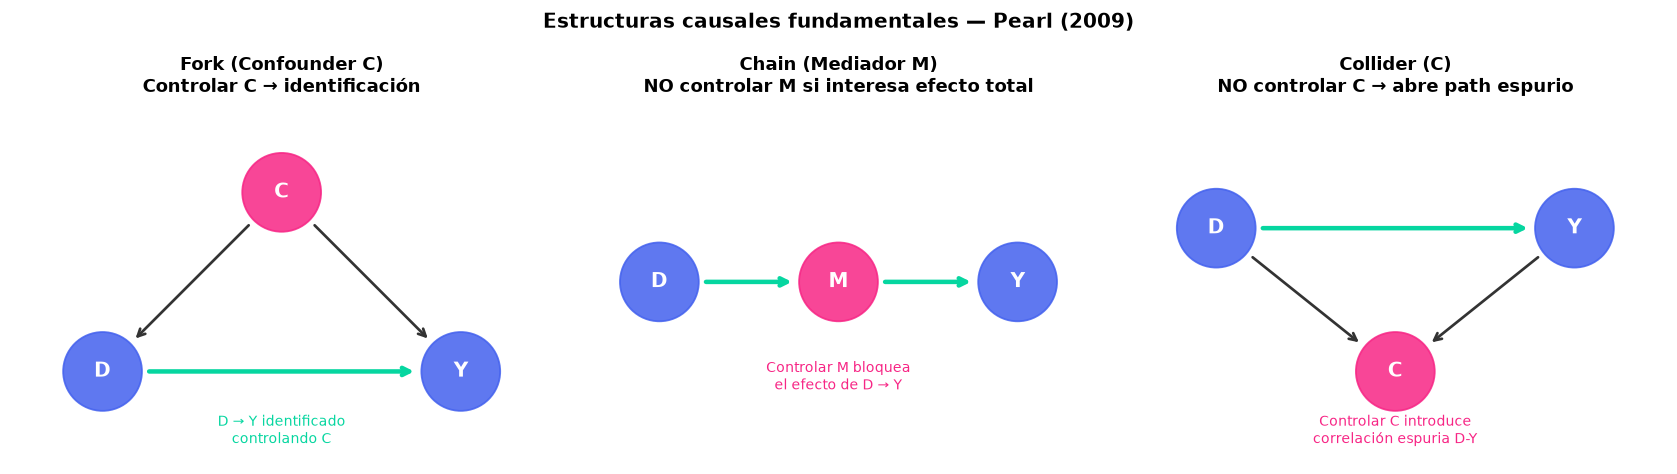

In [3]:
def draw_dag(ax, nodes, edges, title, highlight=None):
    """Dibuja un DAG simple."""
    ax.set_xlim(-0.5, 2.5); ax.set_ylim(-0.5, 1.5)
    ax.set_aspect('equal'); ax.axis('off'); ax.grid(False)
    ax.set_title(title, fontsize=10)

    for name, (x, y) in nodes.items():
        color = '#f72585' if highlight and name in highlight else '#4361ee'
        circle = plt.Circle((x, y), 0.22, color=color, alpha=0.85)
        ax.add_patch(circle)
        ax.text(x, y, name, ha='center', va='center', fontsize=11,
                color='white', fontweight='bold')

    for (src, dst), style in edges.items():
        x0, y0 = nodes[src]; x1, y1 = nodes[dst]
        dx, dy = x1-x0, y1-y0
        length = np.sqrt(dx**2 + dy**2)
        shrink = 0.24
        x0s = x0 + shrink*dx/length; y0s = y0 + shrink*dy/length
        x1s = x1 - shrink*dx/length; y1s = y1 - shrink*dy/length
        color = '#f72585' if style == 'blocked' else '#06d6a0' if style == 'causal' else '#333'
        lw    = 2.5 if style in ('causal', 'blocked') else 1.5
        ax.annotate('', xy=(x1s, y1s), xytext=(x0s, y0s),
                    arrowprops=dict(arrowstyle='->', color=color, lw=lw))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))

# 1. Fork (confounder)
nodes1 = {'C': (1, 1), 'D': (0, 0), 'Y': (2, 0)}
edges1 = {('C','D'): 'fork', ('C','Y'): 'fork', ('D','Y'): 'causal'}
draw_dag(axes[0], nodes1, edges1, 'Fork (Confounder C)\nControlar C → identificación', highlight=['C'])
axes[0].text(1, -0.4, 'D → Y identificado\ncontrolando C', ha='center', fontsize=8, color='#06d6a0')

# 2. Chain (mediador)
nodes2 = {'D': (0, 0.5), 'M': (1, 0.5), 'Y': (2, 0.5)}
edges2 = {('D','M'): 'causal', ('M','Y'): 'causal'}
draw_dag(axes[1], nodes2, edges2, 'Chain (Mediador M)\nNO controlar M si interesa efecto total', highlight=['M'])
axes[1].text(1, -0.1, 'Controlar M bloquea\nel efecto de D → Y', ha='center', fontsize=8, color='#f72585')

# 3. Collider
nodes3 = {'D': (0, 0.8), 'Y': (2, 0.8), 'C': (1, 0)}
edges3 = {('D','C'): 'fork', ('Y','C'): 'fork', ('D','Y'): 'causal'}
draw_dag(axes[2], nodes3, edges3, 'Collider (C)\nNO controlar C → abre path espurio', highlight=['C'])
axes[2].text(1, -0.4, 'Controlar C introduce\ncorrelación espuria D-Y', ha='center', fontsize=8, color='#f72585')

plt.suptitle('Estructuras causales fundamentales — Pearl (2009)', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

## 3 — Backdoor Criterion (Pearl, 2009)

Un conjunto $Z$ satisface el backdoor criterion respecto a $(D, Y)$ si:
1. Ningún nodo de $Z$ es descendiente de $D$
2. $Z$ bloquea todos los caminos de puerta trasera (backdoor paths) entre $D$ e $Y$

Si se satisface: $P(Y|do(D)) = \sum_z P(Y|D,Z=z)P(Z=z)$ — **fórmula de ajuste**.

In [4]:
# Demostración numérica del backdoor criterion
# DAG: X → D, X → Y, D → Y
# Backdoor path: D ← X → Y  → bloquearlo controlando X

# Sin control de X (diferencia bruta)
diff_bruta = df[df['D']==1]['Y'].mean() - df[df['D']==0]['Y'].mean()

# Con control de X: fórmula de ajuste (standardización)
# E[Y(1)] = E_X[E[Y|D=1, X]]
# E[Y(0)] = E_X[E[Y|D=0, X]]
n_bins = 10
df['X_bin'] = pd.qcut(df['X'], q=n_bins, labels=False)

ate_adjusted = 0
for b in range(n_bins):
    bin_data = df[df['X_bin'] == b]
    w = len(bin_data) / n
    treated_mean = bin_data[bin_data['D']==1]['Y'].mean() if bin_data['D'].sum() > 0 else np.nan
    control_mean = bin_data[bin_data['D']==0]['Y'].mean() if (bin_data['D']==0).sum() > 0 else np.nan
    if not (np.isnan(treated_mean) or np.isnan(control_mean)):
        ate_adjusted += w * (treated_mean - control_mean)

# OLS controlando X
mod_ols_x = sm.OLS(df['Y'], sm.add_constant(df[['D', 'X']])).fit()
beta_d_ols = mod_ols_x.params['D']

print('Backdoor Criterion — Pearl (2009)')
print(f'ATE verdadero:                   {df["tau_i"].mean():.4f}')
print(f'Diferencia bruta (sin ajustar):  {diff_bruta:.4f}  ← sesgado')
print(f'Ajuste por bins de X:            {ate_adjusted:.4f}')
print(f'OLS controlando X:               {beta_d_ols:.4f}')
print()
print('Controlar X (que bloquea el backdoor path D ← X → Y)')
print('recupera el ATE bajo CIA.')

Backdoor Criterion — Pearl (2009)
ATE verdadero:                   2.0160
Diferencia bruta (sin ajustar):  3.9240  ← sesgado
Ajuste por bins de X:            1.9361
OLS controlando X:               1.9819

Controlar X (que bloquea el backdoor path D ← X → Y)
recupera el ATE bajo CIA.


## 4 — Sesgo de selección y propensity score

> **Rosenbaum & Rubin (1983):** Si $\{Y(0),Y(1)\} \perp D \mid X$, entonces $\{Y(0),Y(1)\} \perp D \mid p(X)$, donde $p(x) = P(D=1|X=x)$ es el **propensity score**.

Diagnóstico de Overlap (Common Support)
  Tratados  ps: [0.048, 0.978]  media=0.514
  Controles ps: [0.016, 0.905]  media=0.323
  Overlap:      [0.048, 0.905]
  Obs en common support: 2947


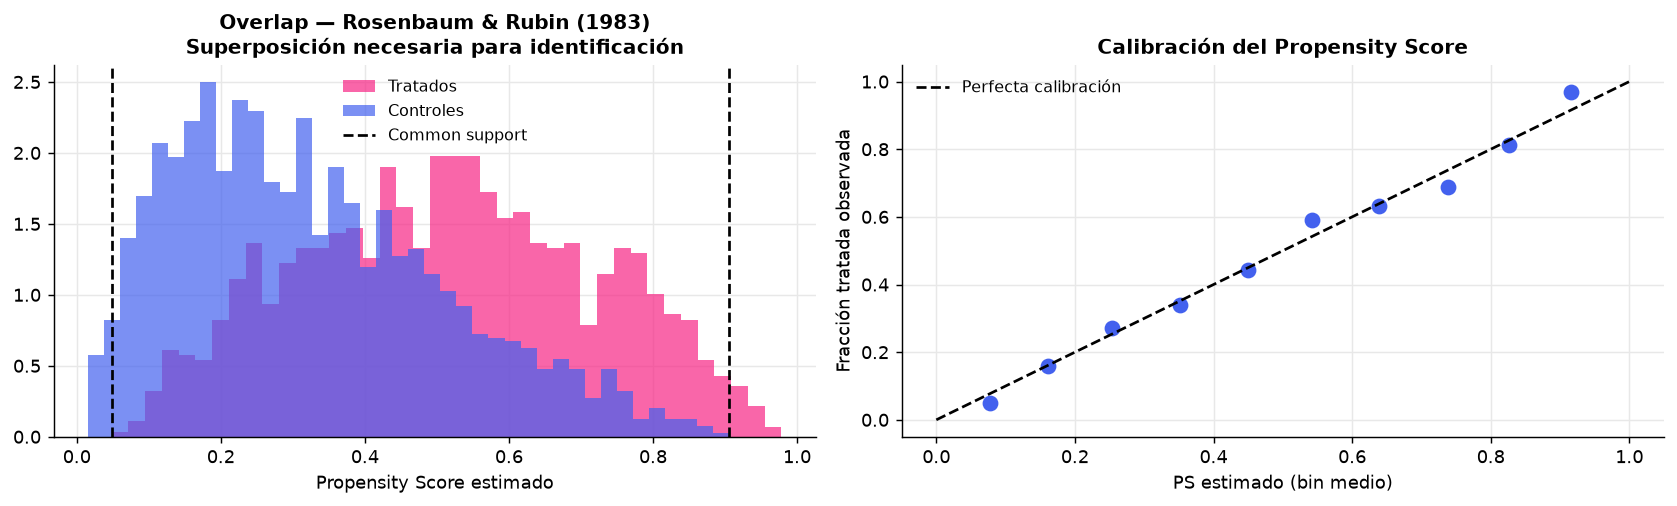

In [5]:
from sklearn.linear_model import LogisticRegression

# Estimar propensity score
lr = LogisticRegression()
lr.fit(df[['X']], df['D'])
df['ps_hat'] = lr.predict_proba(df[['X']])[:, 1]

# Verificar overlap (common support)
ps_treated = df[df['D']==1]['ps_hat']
ps_control = df[df['D']==0]['ps_hat']

overlap_min = max(ps_treated.min(), ps_control.min())
overlap_max = min(ps_treated.max(), ps_control.max())

print('Diagnóstico de Overlap (Common Support)')
print(f'  Tratados  ps: [{ps_treated.min():.3f}, {ps_treated.max():.3f}]  media={ps_treated.mean():.3f}')
print(f'  Controles ps: [{ps_control.min():.3f}, {ps_control.max():.3f}]  media={ps_control.mean():.3f}')
print(f'  Overlap:      [{overlap_min:.3f}, {overlap_max:.3f}]')
print(f'  Obs en common support: {((df["ps_hat"] >= overlap_min) & (df["ps_hat"] <= overlap_max)).sum()}')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(ps_treated, bins=40, color='#f72585', alpha=0.7, density=True, label='Tratados')
axes[0].hist(ps_control, bins=40, color='#4361ee', alpha=0.7, density=True, label='Controles')
axes[0].axvline(overlap_min, color='black', linestyle='--', linewidth=1.5)
axes[0].axvline(overlap_max, color='black', linestyle='--', linewidth=1.5, label='Common support')
axes[0].set_xlabel('Propensity Score estimado')
axes[0].set_title('Overlap — Rosenbaum & Rubin (1983)\nSuperposición necesaria para identificación')
axes[0].legend(fontsize=9)

# Calibración del propensity score
df['ps_bin'] = pd.cut(df['ps_hat'], bins=10)
cal = df.groupby('ps_bin', observed=True).agg(
    obs_treated=('D', 'mean'), ps_mean=('ps_hat', 'mean')).reset_index()
axes[1].scatter(cal['ps_mean'], cal['obs_treated'], s=60, color='#4361ee')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfecta calibración')
axes[1].set_xlabel('PS estimado (bin medio)'); axes[1].set_ylabel('Fracción tratada observada')
axes[1].set_title('Calibración del Propensity Score')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

## Resumen

| Concepto | Fórmula | Referencia |
|---|---|---|
| ATE | $E[Y(1)-Y(0)]$ | Rubin (1974) |
| CIA | $\{Y(0),Y(1)\} \perp D \mid X$ | Rosenbaum & Rubin (1983) |
| Backdoor | Bloquear todos los paths no causales | Pearl (2009) |
| Propensity score | $p(x) = P(D=1|X=x)$ | Rosenbaum & Rubin (1983) |
| Overlap | $0 < p(x) < 1$ para todo $x$ | Imbens & Rubin (2015) |

**Referencias:**
- Rubin, D.B. (1974). Estimating causal effects of treatments. *Journal of Educational Psychology*, 66(5).
- Holland, P.W. (1986). Statistics and causal inference. *JASA*, 81(396).
- Rosenbaum, P.R. & Rubin, D.B. (1983). The central role of the propensity score. *Biometrika*, 70(1).
- Pearl, J. (2009). *Causality: Models, Reasoning, and Inference* (2nd ed.). Cambridge UP.
- Imbens, G.W. & Rubin, D.B. (2015). *Causal Inference for Statistics, Social, and Biomedical Sciences*. Cambridge UP.

**Siguiente:** `05_matching_ipw.ipynb`